## Mojdeh Ghadamim
#### 202405392

# Traditional Models

# Preprocessing Steps

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
import re
import gensim
import spacy


from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from gensim.utils import simple_preprocess
from gensim.models import Phrases

In [105]:
df = pd.read_csv('AG News.csv')
df.describe()

,Class Index
count,127600.000000
mean,2.500000
std,1.118038
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [106]:
df

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
127595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...
127596,2,Void is filled with Clement,With the supply of attractive pitching options...
127597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...
127598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...


In [107]:
# Removing special characters and converting to lower case
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ' , text)
    text = re.sub(r'\s+', ' ' , text).strip()
    return text

df['clean_text'] = (df['Title'] + ' ' + df['Description']).apply(clean_text)

In [108]:
df

,Class Index,Title,Description,clean_text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",wall st bears claw back into the black reuters...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,carlyle looks toward commercial aerospace reut...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,oil and economy cloud stocks outlook reuters r...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,iraq halts oil exports from main southern pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",oil prices soar to all time record posing new ...
...,...,...,...,...
127595,1,Around the world,Ukrainian presidential candidate Viktor Yushch...,around the world ukrainian presidential candid...
127596,2,Void is filled with Clement,With the supply of attractive pitching options...,void is filled with clement with the supply of...
127597,2,Martinez leaves bitter,Like Roger Clemens did almost exactly eight ye...,martinez leaves bitter like roger clemens did ...
127598,3,5 of arthritis patients in Singapore take Bext...,SINGAPORE : Doctors in the United States have ...,5 of arthritis patients in singapore take bext...


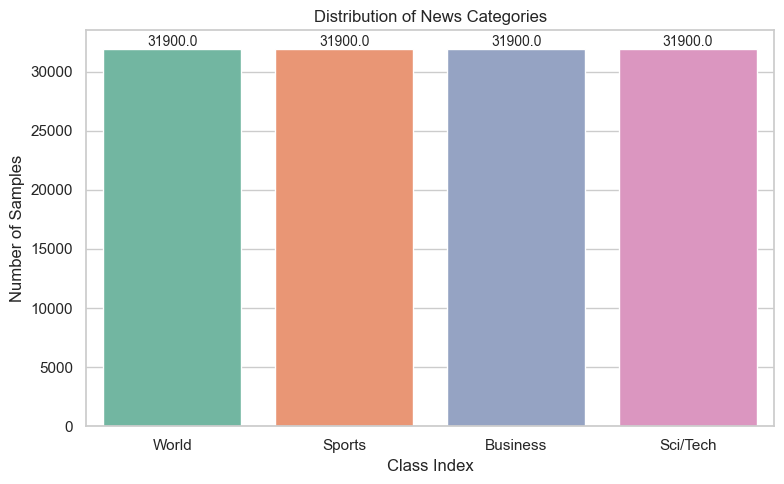

In [109]:
# Set the style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class Index', data=df, palette='Set2')

# Add count labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',                      # The value
                (p.get_x() + p.get_width() / 2, height),  # Position
                ha='center', va='bottom', fontsize=10)    # Align text

# Labels and title
plt.title('Distribution of News Categories')
plt.xlabel('Class Index')
plt.ylabel('Number of Samples')
plt.xticks([0, 1, 2, 3], ['World', 'Sports', 'Business', 'Sci/Tech'])  # Optional: map class names
plt.tight_layout()
plt.show()

In [110]:
# using yield to convert my text from lists of sentences to lists of lists of words

In [111]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(simple_preprocess(sentence, deacc=False))

Tokenization : Converting the text into tokens (words) using simple_preprocess from gensim. This is often the first step in NLP tasks to prepare the text for further processing like stemming, lemmatization, and vectorization.

In [112]:
data = df['clean_text'].to_list()

In [113]:
words = list(sent_to_words(data))

In [114]:
#  Bigrams are pairs of adjacent words in the text

In [115]:
bigram = gensim.models.phrases.Phrases(words, min_count=5, 
                                       threshold=100)
bigram[words]

In [116]:
# Trigrams are sequences of three adjacent words

In [117]:
trigram = gensim.models.phrases.Phrases(bigram[words], threshold=100)

Bigrams and trigrams are useful: 

Bigrams and trigrams capture multi-word expressions that have special meaning when combined (e.g., "New York" or "machine learning").

They provide richer, more informative features for machine learning models.

In [118]:
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

In [119]:
for bigram in bigram_mod.phrasegrams.keys():
    print(bigram)

claw_back
wall_street
afp_afp
mutual_funds
usatoday_com
com_usatoday
retail_sales
bounced_back
jobless_benefits
forbes_com
real_estate
million_barrels
barrels_per
day_bpd
president_purnomo
purnomo_yusgiantoro
highly_anticipated
anticipated_initial
initial_public
public_offering
trade_gap
trade_deficit
these_days
deficit_swells
gets_underway
playboy_magazine
economic_growth
interest_rates
south_african
central_bank
south_korea
percentage_point
search_engine
hewlett_packard
third_quarter
indian_ocean
saudi_arabia
mobile_phone
heart_disease
bargain_hunters
bill_gates
democratic_presidential
presidential_candidate
senator_john
john_kerry
gary_winnick
global_crossing
nuclear_weapons
kevin_rollins
chief_executive
hurricane_charley
hip_hop
middle_class
de_facto
parking_lot
general_motors
manila_philippines
kicked_off
hong_kong
bangkok_thailand
bea_systems
computer_associates
associates_international
even_though
go_ahead
daniel_terdiman
madden_nfl
high_speed
texas_instruments
disc_format
consu

In [120]:
for trigram in trigram_mod.phrasegrams.keys():
    print(trigram)

wall_st
claw_back
wall_street
afp_afp
presidential_elections
mutual_funds
usatoday_com
usatoday_com_usatoday_com
retail_sales
bounced_back
jobless_benefits
forbes_com
forbes_com_forbes_com
general_manager
real_estate
million_barrels
day_bpd
per_day_bpd
president_purnomo
opec_president_purnomo
president_purnomo_yusgiantoro
highly_anticipated
initial_public
initial_public_offering
securities_regulators
trade_gap
trade_deficit
these_days
less_than
gets_underway
playboy_magazine
economic_growth
interest_rates
south_african
central_bank
fell_sharply
south_korea
percentage_point
search_engine
web_search_engine
hewlett_packard
third_quarter
indian_ocean
saudi_arabia
mobile_phone
west_coast
heart_disease
bargain_hunters
bill_gates
president_bush
democratic_presidential
senator_john
senator_john_kerry
gary_winnick
global_crossing
nuclear_weapons
kevin_rollins
chief_executive
hurricane_charley
hip_hop
middle_class
parking_lot
general_motors
manila_philippines
kicked_off
hong_kong
bangkok_thailan

In [121]:
from gensim.parsing.preprocessing import STOPWORDS

Removing stop words:

1. Reduces the size of your vocabulary.

2. Improves signal-to-noise ratio.

3. Helps models focus on meaningful patterns.

4. Makes training faster and sometimes more accurate.

In [122]:
my_stop_words = STOPWORDS.union(set(['br']))

In [123]:
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in my_stop_words] for doc in texts]

In [124]:
data_words_no_stops = remove_stopwords(words)

In [125]:
def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

In [126]:
data_words_bigrams = make_bigrams(data_words_no_stops)
data_words_trigrams = make_trigrams(data_words_no_stops)

In [127]:
for i, text in enumerate(data_words_trigrams):
    for word in text:
        if "_" in word:
            print(i, word)

0 wall_st
0 wall_street
4 afp_afp
4 presidential_elections
6 mutual_funds
7 usatoday_com_usatoday_com
7 retail_sales
7 jobless_benefits
8 forbes_com_forbes_com
8 general_manager
8 real_estate
9 wall_st
9 wall_street
11 million_barrels
11 day_bpd
12 opec_president_purnomo
13 highly_anticipated
13 initial_public_offering
13 securities_regulators
14 trade_gap
14 trade_deficit
17 mutual_funds
18 trade_deficit
18 trade_deficit
20 gets_underway
20 public_offering
20 playboy_magazine
22 economic_growth
23 south_african
23 central_bank
24 fell_sharply
25 south_korea
25 south_korea
25 central_bank
25 percentage_point
26 web_search_engine
27 hewlett_packard
28 indian_ocean
32 saudi_arabia
32 saudi_arabia
32 million_barrels
33 mobile_phone
33 saudi_arabia
34 west_coast
35 heart_disease
36 initial_public_offering
37 bargain_hunters
41 president_bush
41 democratic_presidential
41 senator_john_kerry
45 gary_winnick
45 global_crossing
46 nuclear_weapons
47 kevin_rollins
47 chief_executive
50 hurrican

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [128]:
# Lemmatization reduces words to their root form (e.g., "running" becomes "run", "better" becomes "good").

In [129]:
def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in
                            allowed_postags])
    return texts_out

In [130]:
#using the spacy library to process text and apply lemmatization while keeping only specific parts of speech (nouns, adjectives, verbs, adverbs).

In [131]:
# Initialize spacy 'en' model, keeping only tagger component (for efficiency)
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

# Do lemmatization keeping only noun, adj, vb, adv
data_lemmatized = lemmatization(data_words_trigrams)

print('data_lemmatized[:1]', data_lemmatized[:1])

data_lemmatized[:1] [['bear', 'claw', 'black', 'reuter', 'reuter', 'short', 'seller', 'dwindle', 'band', 'ultra', 'cynic', 'see', 'green']]


In [132]:
# The function getWordCloud creates a visualization of the most frequent words using the WordCloud library

In [133]:
def getWordCloud(hashtags):
    """ https://github.com/amueller/word_cloud """
    
    # Read the whole text.
    text = ' '.join(hashtags)
    # Generate a word cloud image
    wordcloud = WordCloud().generate(text)
    # Display the generated image:
    # the matplotlib way:
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    # lower max_font_size
    wordcloud = WordCloud(max_font_size=40).generate(text)
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.savefig('wordcloud_all.pdf', dpi=500)
    plt.show()

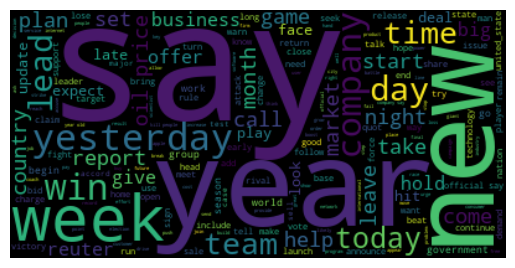

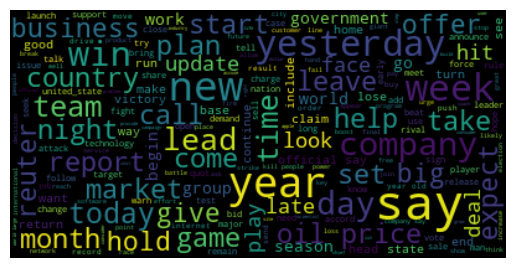

In [134]:
strings = []
for l in data_lemmatized:
    t = ' '.join(l)
    strings.append(t)
getWordCloud(strings)

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfTransformer

In [136]:
# preparing the data for a machine learning model.

In [137]:
pipeline = Pipeline([ 
        ("vect", CountVectorizer()),
        ("tfidf", TfidfTransformer()),
])

In [138]:
X = strings
y = df["Class Index"]  


y = y.astype(int)

print (len(X))
print (len(y))

127600
127600


In [139]:
y

0         3
1         3
2         3
3         3
4         3
         ..
127595    1
127596    2
127597    2
127598    3
127599    3
Name: Class Index, Length: 127600, dtype: int32

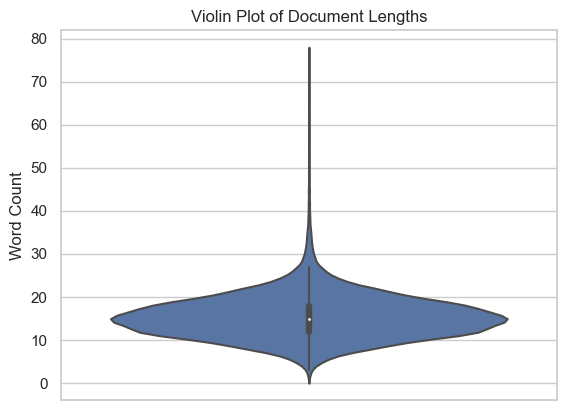

In [141]:
# Length of each document
doc_lengths = [len(doc.split()) for doc in strings]
sns.violinplot(y=doc_lengths)
plt.title("Violin Plot of Document Lengths")
plt.ylabel("Word Count")
plt.show()


In [149]:
y_labels = y.astype(int)
print(y_labels.shape)

(127600,)


# 1) Naive Bayes

In [61]:
xtrain_str, xtest_str, ytrain, ytest = train_test_split(X, y, test_size=0.3)

In [62]:
xtrain = pipeline.fit_transform(xtrain_str)

In [63]:
xtest = pipeline.transform(xtest_str)

In [64]:
print(y.head())         # view sample labels
print(y.unique())       # all class labels
print(y.value_counts()) # count of each class


0    3
1    3
2    3
3    3
4    3
Name: Class Index, dtype: int32
[3 4 2 1]
Class Index
3    31900
4    31900
2    31900
1    31900
Name: count, dtype: int64


In [65]:
# Access the columns in y by their names
print(f"{(y == 1).sum()} world news")
print(f"{(y == 2).sum()} Sport news")
print(f"{(y == 3).sum()} Business news")
print(f"{(y == 4).sum()} Science/Tech news")

31900 world news
31900 Sport news
31900 Business news
31900 Science/Tech news


In [66]:
model = MultinomialNB()

In [67]:
model.fit(xtrain, ytrain)

MultinomialNB()

In [68]:
ypred = model.predict(xtest)

In [69]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           1       0.88      0.87      0.88      9550
           2       0.94      0.95      0.95      9510
           3       0.84      0.85      0.84      9653
           4       0.86      0.84      0.85      9567

    accuracy                           0.88     38280
   macro avg       0.88      0.88      0.88     38280
weighted avg       0.88      0.88      0.88     38280



# 2) SVM

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

In [71]:
# using train and test from previous part

In [72]:
# Create a Support Vector Classifier (SVM) model
svm_model = SVC(kernel='linear')  # Linear kernel (good for text classification)

# Fit the model with the training data
svm_model.fit(xtrain, ytrain)

SVC(kernel='linear')

In [74]:
ypred = svm_model.predict(xtest)

In [64]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           1       0.89      0.87      0.88      9621
           2       0.93      0.96      0.94      9443
           3       0.85      0.85      0.85      9627
           4       0.86      0.86      0.86      9589

    accuracy                           0.88     38280
   macro avg       0.88      0.88      0.88     38280
weighted avg       0.88      0.88      0.88     38280



# 3) Linear SVC

In [91]:
from sklearn.model_selection import train_test_split
X = df['clean_text']

y = pd.get_dummies(df["Class Index"], prefix="Class")

In [92]:
# Convert the one-hot encoded DataFrame y back to the corresponding class labels
y_labels = y.idxmax(axis=1).str.replace('Class_', '').astype(int)

# Check the shape of the converted y_labels
print(y_labels.shape) 

(127600,)


In [93]:
docs_train, docs_test, y_train, y_test = train_test_split(X, y_labels , test_size=0.25, random_state=None)

In [94]:
# Build a vectorizer / classifier pipeline that filters out tokens that are too rare or too frequent

In [95]:
pipeline = Pipeline([
    ('vect', TfidfVectorizer(min_df=3, max_df=0.95)),
    ('clf', LinearSVC(C=1000)),
])

pipeline is a way to chain multiple preprocessing and modeling steps together so that can treat the whole thing like a single model.

TfidfVectorizer	Convert raw text into meaningful numeric vectors using TF-IDF.

'vect': This step applies TfidfVectorizer to the raw text data to convert it into numerical features.

min_df=3: Ignores terms that appear in fewer than 3 documents.

max_df=0.95: Ignores terms that appear in more than 95% of the documents.

'clf': This step applies LinearSVC for classification.

LinearSVC(C=1000): Train a Support Vector Machine classifier to separate the text into categories.

C is a hyperparameter that controls the SVM’s margin. Larger values of C will allow fewer misclassifications but may lead to overfitting.

In [96]:
# Build a grid search to find out whether unigrams or bigrams are more useful.

# Fit the pipeline on the training set using grid search for the parameters

GridSearchCV: This allows you to tune hyperparameters (like ngram_range for the vectorizer) to find the best combination of hyperparameters.

parameters: A dictionary specifying the hyperparameters to search over. In this case, you're exploring the ngram_range of the TfidfVectorizer (which controls whether you use only unigrams, or both unigrams and bigrams).

[(1, 1), (1, 2)] means you'll try two configurations: only unigrams (1, 1) and both unigrams and bigrams (1, 2).

n_jobs=-1: This makes GridSearchCV run on all available CPU cores for faster processing.

fit(docs_train, y_train): This fits the pipeline on the training data, running cross-validation for each hyperparameter combination specified in parameters.

In [97]:
parameters = {
    'vect__ngram_range': [(1, 1), (1, 2)],
}
grid_search = GridSearchCV(pipeline, parameters, n_jobs=-1)
grid_search.fit(docs_train, y_train)

C:\Program Files\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Program Files\Python312\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


GridSearchCV(estimator=Pipeline(steps=[('vect',
                                        TfidfVectorizer(max_df=0.95, min_df=3)),
                                       ('clf', LinearSVC(C=1000))]),
             n_jobs=-1, param_grid={'vect__ngram_range': [(1, 1), (1, 2)]})

In [98]:
# Print the mean and std for each candidate along with the parameter settings for all the candidates explored by grid search.

grid_search.cv_results_: This contains the results of all the cross-validation trials.

'params': The hyperparameter combinations that were tested.

'mean_test_score': The average score across all cross-validation folds.

'std_test_score': The standard deviation of the test scores.

In [99]:
n_candidates = len(grid_search.cv_results_['params'])
for i in range(n_candidates):
    print(i, 'params - %s; mean - %0.2f; std - %0.2f'
             % (grid_search.cv_results_['params'][i],
                grid_search.cv_results_['mean_test_score'][i],
                grid_search.cv_results_['std_test_score'][i]))

0 params - {'vect__ngram_range': (1, 1)}; mean - 0.86; std - 0.00
1 params - {'vect__ngram_range': (1, 2)}; mean - 0.91; std - 0.00


In [100]:
# Predict the outcome on the testing set and store it in a variable named y_predicted

grid_search.predict(docs_test): Once GridSearchCV finishes, it selects the best hyperparameters and refits the model. This line predicts the labels for the test set (docs_test) using the best model found by GridSearchCV.

In [101]:
y_predicted = grid_search.predict(docs_test)

In [102]:
print(metrics.classification_report(y_test, y_predicted))


              precision    recall  f1-score   support

           1       0.92      0.90      0.91      8126
           2       0.96      0.97      0.97      7915
           3       0.88      0.87      0.87      7916
           4       0.87      0.88      0.88      7943

    accuracy                           0.91     31900
   macro avg       0.91      0.91      0.91     31900
weighted avg       0.91      0.91      0.91     31900



Since I am  happy with the results and want to stick with just two n-gram options

# 4) Logistic Regression

In [150]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [151]:
# using x and y from previouse workshope

In [152]:
# Create a Logistic Regression classifier
model = LogisticRegression(max_iter=1000)

# Train the model on the training data
model.fit(xtrain, ytrain)

LogisticRegression(max_iter=1000)

In [153]:
# Make predictions on the test set
y_pred = model.predict(xtest)

# Calculate accuracy
accuracy = accuracy_score(ytest, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Display classification report for more detailed performance metrics
print(classification_report(ytest, ypred))

Accuracy: 88.05%
              precision    recall  f1-score   support

           1       0.89      0.87      0.88      9550
           2       0.93      0.96      0.94      9510
           3       0.85      0.86      0.86      9653
           4       0.87      0.86      0.86      9567

    accuracy                           0.89     38280
   macro avg       0.88      0.89      0.88     38280
weighted avg       0.88      0.89      0.88     38280



In [154]:
# second: using a simpler version

In [155]:
# Loading the Data and Preparing Target Variable (y)

In [156]:
from sklearn.model_selection import train_test_split
X = df['clean_text']

y = pd.get_dummies(df["Class Index"], prefix="Class")

In [157]:
# Convert the one-hot encoded DataFrame y back to the corresponding class labels
y_labels = y.idxmax(axis=1).str.replace('Class_', '').astype(int)

# Check the shape of the converted y_labels
print(y_labels.shape) 

(127600,)


In [158]:
train_x, test_x, train_y, test_y = train_test_split(X, y_labels , test_size=0.25, random_state=None)

TfidfVectorizer is a method that converts text data into a numerical representation. It’s one of the most commonly used methods to vectorize text. It stands for Term Frequency-Inverse Document Frequency and captures how important a word is in a document relative to all other documents in the dataset.

stop_words='english': This removes common words (like "the", "a", "is", etc.) from the text, which don't carry much meaningful information in the context of classification tasks.

max_features=5000: This limits the number of features (words) that the vectorizer considers, which helps reduce dimensionality and computation time. In this case, only the 5,000 most important words are considered.

In [159]:
# Vectorize the text data using TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(train_x)
X_test_tfidf = vectorizer.transform(test_x)

In [160]:
# Create a Logistic Regression classifier
model = LogisticRegression(max_iter=1000)

# Train the model on the training data
model.fit(X_train_tfidf, train_y)


LogisticRegression(max_iter=1000)

In [161]:
# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(test_y, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Display classification report for more detailed performance metrics
print(classification_report(test_y, y_pred))

Accuracy: 90.71%
              precision    recall  f1-score   support

           1       0.92      0.89      0.91      7975
           2       0.95      0.98      0.96      7970
           3       0.88      0.88      0.88      8038
           4       0.88      0.88      0.88      7917

    accuracy                           0.91     31900
   macro avg       0.91      0.91      0.91     31900
weighted avg       0.91      0.91      0.91     31900



In [162]:
X = df['clean_text']
y = pd.get_dummies(df["Class Index"], prefix="Class")
y_labels = y.idxmax(axis=1).str.replace('Class_', '').astype(int)

# Split data into train/test (80/20)
train_x, test_x, train_y, test_y = train_test_split(X, y_labels, test_size=0.2, stratify=y_labels, random_state=42)

# Optional: Use a smaller subset for hyperparameter tuning to speed things up
train_x_small, _, train_y_small, _ = train_test_split(train_x, train_y, train_size=10000, stratify=train_y, random_state=42)

# Define hyperparameters for Logistic Regression
param_grid = {
    'lr__C': [0.1, 1],
    'lr__solver': ['liblinear'],
    'lr__penalty': ['l2'],
    'tfidf__max_df': [0.9],
    'tfidf__min_df': [5],
    'tfidf__ngram_range': [(1, 1)]
}


# Setup a pipeline to combine TF-IDF and Logistic Regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('lr', LogisticRegression(max_iter=1000))
])

# Use RandomizedSearchCV to reduce computation time
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=20,  # Only try 20 random combinations
    cv=3,       # Fewer folds to speed up
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit on smaller subset
random_search.fit(train_x_small, train_y_small)

# Best parameters
print("Best parameters found:")
print(random_search.best_params_)

# Evaluate on the real test set
best_model = random_search.best_estimator_
y_pred = best_model.predict(test_x)

# Accuracy and classification report
print(f"Test Accuracy: {accuracy_score(test_y, y_pred) * 100:.2f}%")
print("Classification Report:")
print(classification_report(test_y, y_pred))

C:\Program Files\Python312\Lib\site-packages\sklearn\model_selection\_search.py:318: UserWarning: The total space of parameters 2 is smaller than n_iter=20. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters found:
{'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 5, 'tfidf__max_df': 0.9, 'lr__solver': 'liblinear', 'lr__penalty': 'l2', 'lr__C': 1}
Test Accuracy: 89.47%
Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.89      0.90      6380
           2       0.93      0.97      0.95      6380
           3       0.88      0.86      0.87      6380
           4       0.87      0.86      0.87      6380

    accuracy                           0.89     25520
   macro avg       0.89      0.89      0.89     25520
weighted avg       0.89      0.89      0.89     25520



# 5) Random Forest

In [174]:
from sklearn.ensemble import RandomForestClassifier  # Random Forest

In [175]:
from sklearn.model_selection import train_test_split
X = df['clean_text']

y = pd.get_dummies(df["Class Index"], prefix="Class")

In [176]:
# Convert the one-hot encoded DataFrame y back to the corresponding class labels
y_labels = y.idxmax(axis=1).str.replace('Class_', '').astype(int)

# Check the shape of the converted y_labels
print(y_labels.shape) 

(127600,)


In [177]:
train_x, test_x, train_y, test_y = train_test_split(X, y_labels , test_size=0.25, random_state=None)

In [178]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the text data using TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(train_x)
X_test_tfidf = vectorizer.transform(test_x)

In [179]:
# Create a Random Forest classifier (you can adjust hyperparameters)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the vectorized training data
rf_model.fit(X_train_tfidf, train_y)

RandomForestClassifier(random_state=42)

In [180]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test_tfidf)

In [181]:
# Evaluate the model using accuracy and a classification report
accuracy = accuracy_score(test_y, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(test_y, y_pred))

Accuracy: 88.25%
              precision    recall  f1-score   support

           1       0.90      0.87      0.88      7956
           2       0.91      0.96      0.94      8009
           3       0.86      0.85      0.86      8044
           4       0.86      0.84      0.85      7891

    accuracy                           0.88     31900
   macro avg       0.88      0.88      0.88     31900
weighted avg       0.88      0.88      0.88     31900



In [167]:
# using train and test from previous part (tokenization, stopword removal, bigrams/trigrams, lemmatization)

In [165]:
# Create a Random Forest classifier (you can adjust hyperparameters)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [166]:
# Train the model using the vectorized training data
rf_model.fit(xtrain, ytrain)

RandomForestClassifier(random_state=42)

In [168]:
ypred = rf_model.predict(xtest)

In [169]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           1       0.84      0.84      0.84      9550
           2       0.87      0.94      0.90      9510
           3       0.82      0.82      0.82      9653
           4       0.85      0.79      0.82      9567

    accuracy                           0.84     38280
   macro avg       0.84      0.84      0.84     38280
weighted avg       0.84      0.84      0.84     38280



# 6) XGboost

In [172]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [173]:
le = LabelEncoder()
ytrain_encoded = le.fit_transform(ytrain)
ytest_encoded = le.transform(ytest) 


# Initialize the XGBoost classifier
xgb_classifier = xgb.XGBClassifier()

# Train 
xgb_classifier.fit(xtrain, ytrain_encoded)

# Predict 
validation_predictions_xgb_encoded = xgb_classifier.predict(xtest)

print(classification_report(ytest_encoded, validation_predictions_xgb_encoded))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      9550
           1       0.84      0.92      0.88      9510
           2       0.82      0.80      0.81      9653
           3       0.83      0.78      0.80      9567

    accuracy                           0.83     38280
   macro avg       0.83      0.83      0.83     38280
weighted avg       0.83      0.83      0.83     38280



In [48]:
# using another method for cleaning the data

In [69]:
X = df['clean_text']

y = pd.get_dummies(df["Class Index"], prefix="Class")

In [70]:
# Convert the one-hot encoded DataFrame y back to the corresponding class labels
y_labels = y.idxmax(axis=1).str.replace('Class_', '').astype(int)

# Check the shape of the converted y_labels
print(y_labels.shape) 

(127600,)


In [71]:
train_x, test_x, train_y, test_y = train_test_split(X, y_labels , test_size=0.25, random_state=None)

In [73]:
# Initialize LabelEncoder to encode the target labels
le = LabelEncoder()

# Fit and transform the training labels, and transform the test labels
train_y_encoded = le.fit_transform(train_y)
test_y_encoded = le.transform(test_y)

In [75]:
# Vectorize the text data using TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(train_x)
X_test_tfidf = vectorizer.transform(test_x)

In [76]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

# Initialize the XGBoost classifier
xgb_classifier = xgb.XGBClassifier()

# Train the model
xgb_classifier.fit(X_train_tfidf, train_y_encoded)

# Predict the encoded labels for the test set
validation_predictions_xgb_encoded = xgb_classifier.predict(X_test_tfidf)

# Decode the predicted labels back to the original class labels
validation_predictions_xgb = le.inverse_transform(validation_predictions_xgb_encoded)

# Evaluate the model using classification_report
print(classification_report(test_y, validation_predictions_xgb))

              precision    recall  f1-score   support

           1       0.90      0.87      0.89      7927
           2       0.92      0.95      0.94      7858
           3       0.86      0.86      0.86      8070
           4       0.85      0.85      0.85      8045

    accuracy                           0.88     31900
   macro avg       0.88      0.88      0.88     31900
weighted avg       0.88      0.88      0.88     31900



# a visual comparison (bar chart)

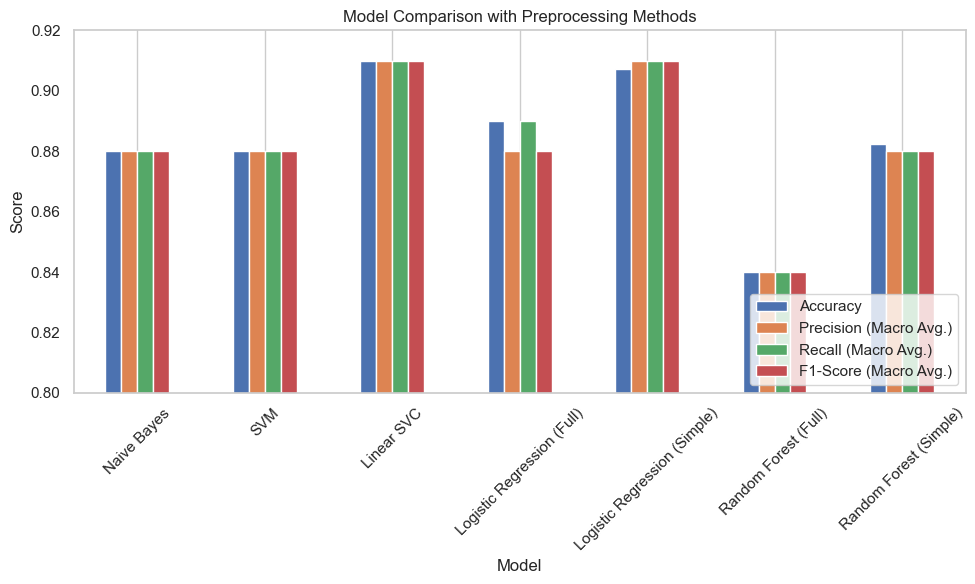

In [183]:
# Data from metrics
data = {
    "Model": ["Naive Bayes", "SVM", "Linear SVC", "Logistic Regression (Full)", "Logistic Regression (Simple)",
              "Random Forest (Full)", "Random Forest (Simple)"],
    "Accuracy": [0.88, 0.88, 0.91, 0.89, 0.9071, 0.84, 0.8825],
    "Precision (Macro Avg.)": [0.88, 0.88, 0.91, 0.88, 0.91, 0.84, 0.88],
    "Recall (Macro Avg.)": [0.88, 0.88, 0.91, 0.89, 0.91, 0.84, 0.88],
    "F1-Score (Macro Avg.)": [0.88, 0.88, 0.91, 0.88, 0.91, 0.84, 0.88]
}

# Create DataFrame
df = pd.DataFrame(data)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
df.set_index("Model").plot(kind="bar", ax=ax)
plt.title("Model Comparison with Preprocessing Methods")
plt.ylabel("Score")
plt.ylim(0.80, 0.92)  # Adjusted to fit the scores better
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()


# Deep learning

# 1) BiLSTM

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [25]:
# Load and prepare data
train = pd.read_csv('train.csv')
train['title'] = train['Title'].astype(str) + " " + train['Description'].astype(str)
test = pd.read_csv('test.csv')
test['title'] = test['Title'].astype(str) + " " + test['Description'].astype(str)


# Combine train and test for full dataset
df_train_selected = train[['title', 'Class Index']]
df_test_selected = test[['title', 'Class Index']]
data = pd.concat([df_train_selected, df_test_selected], ignore_index=True)
data.columns = data.columns.str.lower()  # Make column names lowercase

In [26]:
# Prepare text and labels
texts = data["title"]
labels = data["class index"] - 1  # Shift labels from 1-4 to 0-3

In [27]:
# Split into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(texts, labels, test_size=0.2, random_state=42)

In [28]:
# Tokenize and pad sequences
max_features = 20000
maxlen = 200

tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_val_seq = tokenizer.texts_to_sequences(x_val)

x_train_pad = pad_sequences(x_train_seq, maxlen=maxlen)
x_val_pad = pad_sequences(x_val_seq, maxlen=maxlen)


In [84]:
# Build the model
inputs = keras.Input(shape=(None,), dtype="int32")
x = layers.Embedding(max_features, 128)(inputs)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
outputs = layers.Dense(4, activation="softmax")(x)



model = keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, None, 128)           │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, None, 128)           │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,758,148 (10.52 MB)

 Trainable params: 2,758,148 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
# Train the model
model.fit(x_train_pad, y_train, validation_data=(x_val_pad, y_val), epochs=5, batch_size=64)

Epoch 1/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 203s 126ms/step - accuracy: 0.8229 - loss: 0.4805 - val_accuracy: 0.9163 - val_loss: 0.2674
Epoch 2/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 211s 132ms/step - accuracy: 0.9376 - loss: 0.1991 - val_accuracy: 0.9172 - val_loss: 0.2618
Epoch 3/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 223s 140ms/step - accuracy: 0.9531 - loss: 0.1480 - val_accuracy: 0.9147 - val_loss: 0.2741
Epoch 4/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 227s 142ms/step - accuracy: 0.9664 - loss: 0.1040 - val_accuracy: 0.9132 - val_loss: 0.3119
Epoch 5/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 231s 145ms/step - accuracy: 0.9759 - loss: 0.0724 - val_accuracy: 0.9061 - val_loss: 0.3339


 How to improve the model?

In [85]:
#hypertining using drop

inputs = keras.Input(shape=(None,), dtype="int32")
x = layers.Embedding(max_features, 128)(inputs)
x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)
)(x)
x = layers.Bidirectional(
    layers.LSTM(64, dropout=0.3, recurrent_dropout=0.3)
)(x)
outputs = layers.Dense(4, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, None)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, None, 128)           │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, None, 128)           │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,758,148 (10.52 MB)

 Trainable params: 2,758,148 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
# Train the model
model.fit(x_train_pad, y_train, validation_data=(x_val_pad, y_val), epochs=5, batch_size=64)

Epoch 1/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 823s 514ms/step - accuracy: 0.7663 - loss: 0.5664 - val_accuracy: 0.9152 - val_loss: 0.2712
Epoch 2/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 875s 549ms/step - accuracy: 0.9286 - loss: 0.2326 - val_accuracy: 0.9165 - val_loss: 0.2651
Epoch 3/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 862s 540ms/step - accuracy: 0.9414 - loss: 0.1888 - val_accuracy: 0.9165 - val_loss: 0.2718
Epoch 4/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 866s 543ms/step - accuracy: 0.9515 - loss: 0.1548 - val_accuracy: 0.9114 - val_loss: 0.2833
Epoch 5/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 869s 545ms/step - accuracy: 0.9568 - loss: 0.1322 - val_accuracy: 0.9071 - val_loss: 0.3076


In [18]:
# Dropout applied between layers (instead of inside LSTM) 
# Dropout rate reduced to 0.2 (instead of 0.3) 
#Learning rate decreased to 0.0005 for more stable updates 
#Added LayerNormalization() for improved activation stability

In [29]:
# Build the model
inputs = keras.Input(shape=(None,), dtype="int32")
x = layers.Embedding(max_features, 128)(inputs)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)  
x = layers.Dropout(0.2)(x)  # Reduced dropout rate applied BETWEEN layers
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Dropout(0.2)(x)  # Dropout before the output Dense layer
x = layers.LayerNormalization()(x)  # Normalize activations for stability
outputs = layers.Dense(4, activation="softmax")(x)

# Compile model with optimized learning rate
model = keras.Model(inputs, outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train the model
model.fit(x_train_pad, y_train, validation_data=(x_val_pad, y_val), epochs=5, batch_size=64)

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, None)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_8 (Embedding)              │ (None, None, 128)           │       2,560,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, None, 128)           │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, None, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization_6                │ (None, 128)                 │             256 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,758,404 (10.52 MB)

 Trainable params: 2,758,404 (10.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 243s 151ms/step - accuracy: 0.8134 - loss: 0.4917 - val_accuracy: 0.9149 - val_loss: 0.2620
Epoch 2/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 240s 151ms/step - accuracy: 0.9412 - loss: 0.1832 - val_accuracy: 0.9133 - val_loss: 0.2672
Epoch 3/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 227s 143ms/step - accuracy: 0.9560 - loss: 0.1328 - val_accuracy: 0.9106 - val_loss: 0.3047
Epoch 4/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 229s 143ms/step - accuracy: 0.9687 - loss: 0.0945 - val_accuracy: 0.9074 - val_loss: 0.3601
Epoch 5/5
1595/1595 ━━━━━━━━━━━━━━━━━━━━ 233s 146ms/step - accuracy: 0.9773 - loss: 0.0686 - val_accuracy: 0.8999 - val_loss: 0.4023


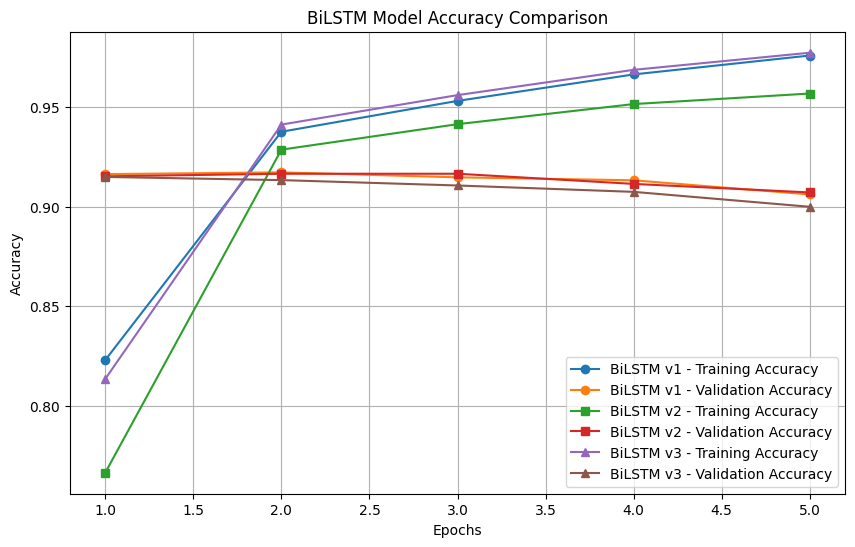

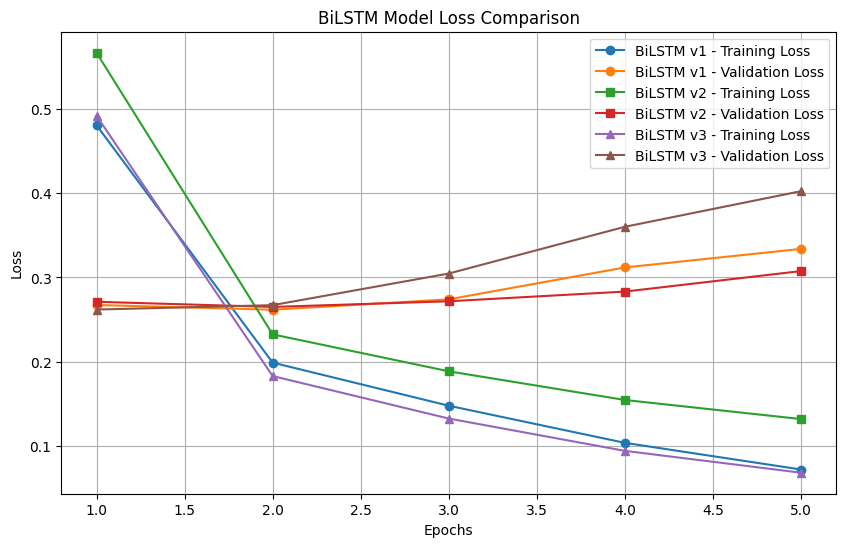

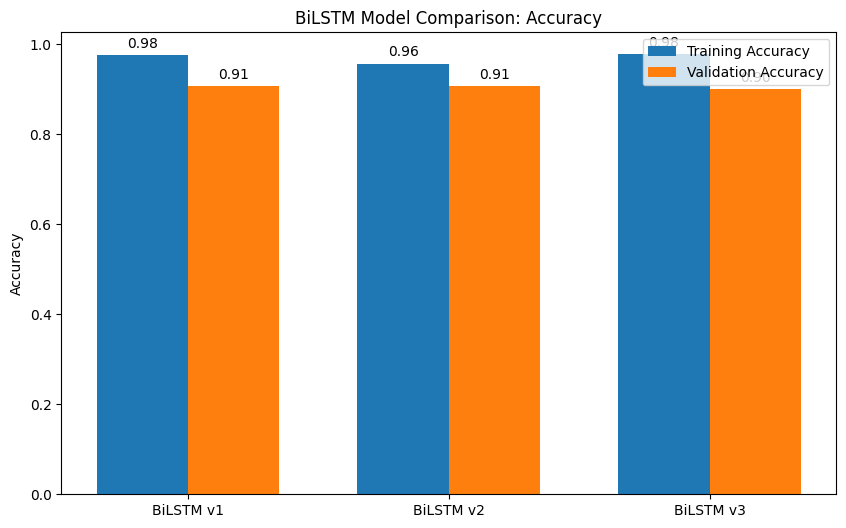

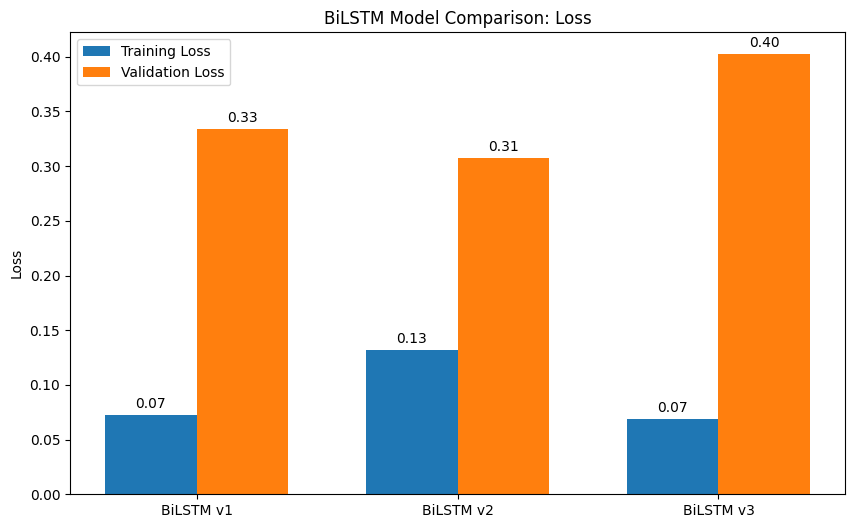

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Data for training and validation accuracy and loss
epochs = [1, 2, 3, 4, 5]

# BiLSTM (v1) Data 
bilstm_v1_accuracy = [0.8229, 0.9376, 0.9531, 0.9664, 0.9759]
bilstm_v1_val_accuracy = [0.9163, 0.9172, 0.9147, 0.9132, 0.9061]
bilstm_v1_loss = [0.4805, 0.1991, 0.1480, 0.1040, 0.0724]
bilstm_v1_val_loss = [0.2674, 0.2618, 0.2741, 0.3119, 0.3339]

# BiLSTM (v2) Data
bilstm_v2_accuracy = [0.7663, 0.9286, 0.9414, 0.9515, 0.9568]
bilstm_v2_val_accuracy = [0.9152, 0.9165, 0.9165, 0.9114, 0.9071]
bilstm_v2_loss = [0.5664, 0.2326, 0.1888, 0.1548, 0.1322]
bilstm_v2_val_loss = [0.2712, 0.2651, 0.2718, 0.2833, 0.3076]

# BiLSTM (v3) Data
bilstm_v3_accuracy = [0.8134, 0.9412, 0.9560, 0.9687, 0.9773]
bilstm_v3_val_accuracy = [0.9149, 0.9133, 0.9106, 0.9074, 0.8999]
bilstm_v3_loss = [0.4917, 0.1832, 0.1328, 0.0945, 0.0686]
bilstm_v3_val_loss = [0.2620, 0.2672, 0.3047, 0.3601, 0.4023]

# Create a plot for Accuracy
plt.figure(figsize=(10, 6))

plt.plot(epochs, bilstm_v1_accuracy, label='BiLSTM v1 - Training Accuracy', marker='o')
plt.plot(epochs, bilstm_v1_val_accuracy, label='BiLSTM v1 - Validation Accuracy', marker='o')

plt.plot(epochs, bilstm_v2_accuracy, label='BiLSTM v2 - Training Accuracy', marker='s')
plt.plot(epochs, bilstm_v2_val_accuracy, label='BiLSTM v2 - Validation Accuracy', marker='s')

plt.plot(epochs, bilstm_v3_accuracy, label='BiLSTM v3 - Training Accuracy', marker='^')
plt.plot(epochs, bilstm_v3_val_accuracy, label='BiLSTM v3 - Validation Accuracy', marker='^')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('BiLSTM Model Accuracy Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Create a plot for Loss
plt.figure(figsize=(10, 6))

plt.plot(epochs, bilstm_v1_loss, label='BiLSTM v1 - Training Loss', marker='o')
plt.plot(epochs, bilstm_v1_val_loss, label='BiLSTM v1 - Validation Loss', marker='o')

plt.plot(epochs, bilstm_v2_loss, label='BiLSTM v2 - Training Loss', marker='s')
plt.plot(epochs, bilstm_v2_val_loss, label='BiLSTM v2 - Validation Loss', marker='s')

plt.plot(epochs, bilstm_v3_loss, label='BiLSTM v3 - Training Loss', marker='^')
plt.plot(epochs, bilstm_v3_val_loss, label='BiLSTM v3 - Validation Loss', marker='^')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('BiLSTM Model Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Now let's visualize the comparison between the three BiLSTM versions (v1, v2, v3)

# Accuracy comparison bar chart
models = ['BiLSTM v1', 'BiLSTM v2', 'BiLSTM v3']
train_accuracy = [bilstm_v1_accuracy[-1], bilstm_v2_accuracy[-1], bilstm_v3_accuracy[-1]]
val_accuracy = [bilstm_v1_val_accuracy[-1], bilstm_v2_val_accuracy[-1], bilstm_v3_val_accuracy[-1]]

x = np.arange(len(models))  # label positions
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, train_accuracy, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, val_accuracy, width, label='Validation Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('BiLSTM Model Comparison: Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add labels for better readability
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(rects1)
add_labels(rects2)

plt.show()

# Loss comparison bar chart
train_loss = [bilstm_v1_loss[-1], bilstm_v2_loss[-1], bilstm_v3_loss[-1]]
val_loss = [bilstm_v1_val_loss[-1], bilstm_v2_val_loss[-1], bilstm_v3_val_loss[-1]]

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, train_loss, width, label='Training Loss')
rects2 = ax.bar(x + width/2, val_loss, width, label='Validation Loss')

ax.set_ylabel('Loss')
ax.set_title('BiLSTM Model Comparison: Loss')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Add labels for better readability
add_labels(rects1)
add_labels(rects2)

plt.show()


# 2) Transformer

In [22]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# Load the data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Merge 'Title' and 'Description' columns
train['title'] = train['Title'].astype(str) + train['Description'].astype(str)
x_train = train['title']
y_train = train['Class Index']

test['title'] = test['Title'].astype(str) + test['Description'].astype(str)
x_test = test['title']
y_test = test['Class Index']


# One-hot encode labels
y_train = to_categorical(y_train - 1, num_classes=4)  # Subtract 1 to make the labels 0-indexed
y_test = to_categorical(y_test - 1, num_classes=4)    # Subtract 1 to make the labels 0-indexed

In [6]:
# Tokenizer to convert text into sequences of integers
tokenizer = keras.preprocessing.text.Tokenizer(num_words=20000)  # Only consider the top 20k words
tokenizer.fit_on_texts(x_train)  # Fit tokenizer on the training data

# Convert texts to sequences of integers
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

# Padding the sequences to ensure equal length
maxlen = 200  # Only consider the first 200 words of each document
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print(len(x_train), "Training sequences")
print(len(x_test), "Test sequences")


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.001):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):  # Add the 'training' argument here
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


embed_dim = 128
num_heads = 4
ff_dim = 512

inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size=20000, embed_dim=embed_dim)(inputs)

# Now call the TransformerBlock with the correct input
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)(embedding_layer)

# Add pooling, dense layers, and output layers
x = layers.GlobalAveragePooling1D()(transformer_block)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(4, activation='softmax')(x)  # 4 units with softmax activation

# Define and compile the model
model = keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model (this is just an example, you might want to split the data further)
model.fit(x_train, y_train, epochs=3, batch_size=64, validation_data=(x_test, y_test))


120000 Training sequences
7600 Test sequences
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 427s 226ms/step - accuracy: 0.6295 - loss: 0.7757 - val_accuracy: 0.9157 - val_loss: 0.2550
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 421s 225ms/step - accuracy: 0.9354 - loss: 0.1946 - val_accuracy: 0.9176 - val_loss: 0.2638
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 424s 226ms/step - accuracy: 0.9479 - loss: 0.1468 - val_accuracy: 0.9104 - val_loss: 0.2997


In [13]:
# epochs = 5

In [2]:
# Tokenizer to convert text into sequences of integers
tokenizer = keras.preprocessing.text.Tokenizer(num_words=20000)  # Only consider the top 20k words
tokenizer.fit_on_texts(x_train)  # Fit tokenizer on the training data

# Convert texts to sequences of integers
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

# Padding the sequences to ensure equal length
maxlen = 200  # Only consider the first 200 words of each document
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print(len(x_train), "Training sequences")
print(len(x_test), "Test sequences")


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.001):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        )
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):  # Add the 'training' argument here
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


embed_dim = 128
num_heads = 4
ff_dim = 512

inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size=20000, embed_dim=embed_dim)(inputs)

# Now call the TransformerBlock with the correct input
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)(embedding_layer)

# Add pooling, dense layers, and output layers
x = layers.GlobalAveragePooling1D()(transformer_block)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(4, activation='softmax')(x)  # 4 units with softmax activation

# Define and compile the model
model = keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model (this is just an example, you might want to split the data further)
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))


120000 Training sequences
7600 Test sequences

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 217s 115ms/step - accuracy: 0.7391 - loss: 0.5982 - val_accuracy: 0.9136 - val_loss: 0.2691
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 224s 120ms/step - accuracy: 0.9372 - loss: 0.1871 - val_accuracy: 0.9125 - val_loss: 0.2740
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 237s 127ms/step - accuracy: 0.9486 - loss: 0.1427 - val_accuracy: 0.9158 - val_loss: 0.2668
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 226s 120ms/step - accuracy: 0.9582 - loss: 0.1135 - val_accuracy: 0.9099 - val_loss: 0.3117
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 224s 119ms/step - accuracy: 0.9632 - loss: 0.0933 - val_accuracy: 0.9096 - val_loss: 0.3398


In [ ]:
# Dropout moved to the pooling layer → Prevents excessive regularization inside Transformer 
# Reduced learning rate (0.0005) → Stabilizes training across longer epochs 
# Early stopping callback added → Avoids unnecessary training if validation accuracy stops improving 
# Batch size increased to 128 → Helps smoother learning with large datasets

In [23]:
# Tokenizer to convert text into sequences of integers
tokenizer = keras.preprocessing.text.Tokenizer(num_words=20000)
tokenizer.fit_on_texts(x_train)

# Convert texts to sequences of integers
x_train = tokenizer.texts_to_sequences(x_train)
x_test = tokenizer.texts_to_sequences(x_test)

# Padding sequences to ensure equal length
maxlen = 200
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print(len(x_train), "Training sequences")
print(len(x_test), "Test sequences")

# Define Transformer block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.3):
        super(TransformerBlock, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Define embedding layer
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

# Model hyperparameters
embed_dim = 128
num_heads = 4
ff_dim = 512

# Build model
inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size=20000, embed_dim=embed_dim)(inputs)

# Apply Transformer block
transformer_block = TransformerBlock(embed_dim, num_heads, ff_dim)(embedding_layer)

# Add pooling, dropout, dense layers, and output layers
x = layers.GlobalAveragePooling1D()(transformer_block)
x = layers.Dropout(0.3)(x)  # Apply dropout after pooling for better regularization
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(4, activation='softmax')(x)  

# Define and compile the model with optimized learning rate
model = keras.Model(inputs, outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), 
              loss="categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Apply early stopping callback
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train model
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_test, y_test), callbacks=[callback])


120000 Training sequences
7600 Test sequences


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ token_and_position_embedding_2       │ (None, 200, 128)            │       2,585,600 │
│ (TokenAndPositionEmbedding)          │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_2                  │ (None, 200, 128)            │         396,032 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_2           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,992,100 (11.41 MB)

 Trainable params: 2,992,100 (11.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 233s 246ms/step - accuracy: 0.5305 - loss: 0.9607 - val_accuracy: 0.9149 - val_loss: 0.2633
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 256s 240ms/step - accuracy: 0.9339 - loss: 0.2061 - val_accuracy: 0.9189 - val_loss: 0.2529
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 227s 241ms/step - accuracy: 0.9477 - loss: 0.1573 - val_accuracy: 0.9172 - val_loss: 0.2745
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 226s 240ms/step - accuracy: 0.9548 - loss: 0.1329 - val_accuracy: 0.9107 - val_loss: 0.3198


# Preparing Data For GRU, RNN, and LSTM

In [32]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [33]:
# Load your data
data = pd.read_csv('AG News.csv', na_values=['no info', '.'])

# Merge 'Title' and 'Description' columns
data['title'] = data['Title'].astype(str) + data['Description'].astype(str)

data = pd.DataFrame({
    'text': data['title'],
    'label': data['Class Index']
})

data

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,3
1,Carlyle Looks Toward Commercial Aerospace (Reu...,3
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,3
3,Iraq Halts Oil Exports from Main Southern Pipe...,3
4,"Oil prices soar to all-time record, posing new...",3
...,...,...
127595,Around the worldUkrainian presidential candida...,1
127596,Void is filled with ClementWith the supply of ...,2
127597,Martinez leaves bitterLike Roger Clemens did a...,2
127598,5 of arthritis patients in Singapore take Bext...,3


In [34]:
import re
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

x = []
y = []

num_classes = 4

def process_sentence(sentence):
    '''Removes all special characters from sentence. It will also strip out
    extra whitespace and makes the string lowercase.
    '''
    return re.sub(r'[\\\\/:*«`\'?¿";!<>,.|]', '', sentence.lower().strip())

# As our sentences in all_sentences.txt are in order, we need to shuffle it first.
sss = StratifiedShuffleSplit(test_size=0.2, random_state=0)

# Clean the sentences
X = data["text"].apply(process_sentence)
y = data['label']

print('YYYYYYY',y)

# Split all our sentences
elements = (' '.join([sentence for sentence in X])).split()

X_train, X_test, y_train, y_test = None, None, None, None

for train_index, test_index in sss.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]    

# Set identifies the unique possible labels
labels = set(y)

len(X_train), len(X_test)

YYYYYYY 0         3
1         3
2         3
3         3
4         3
         ..
127595    1
127596    2
127597    2
127598    3
127599    3
Name: label, Length: 127600, dtype: int64


(102080, 25520)

In [35]:
print("Feature Shapes:")
print("\tTrain set: \t\t{}".format(X_train.shape),
      "\n\tTest set: \t\t{}".format(X_test.shape))
print("Totals:\n\tWords in our Dataset: {}\n\tLabels: {}".format(len(elements), len(labels)))

# Lets look at our training data
X_train[:10], y_train[:10]

Feature Shapes:
	Train set: 		(102080,) 
	Test set: 		(25520,)
Totals:
	Words in our Dataset: 4706008
	Labels: 4


(11414     dechy stuns capriati 6-4 7-5 at pilot pen (ap)...
 111011    oil chips to crimp stocksrise in oil prices ah...
 27551     larsson goal caps return to celtic as barca wi...
 49988     at t wireless to offer music downloads (ap)ap ...
 98887     sc football coach holtz calls it quitssouth ca...
 3734      after wait google set for market debutnew york...
 14744     france rejects iraqi kidnappers #39 demand on ...
 121153    quick duff puts kerr #39s men into fast lanebr...
 67548     us indicators fall 4th month straight washingt...
 65157     knee inflammation limits nash #39s playing tim...
 Name: text, dtype: object,
 11414     2
 111011    3
 27551     2
 49988     4
 98887     2
 3734      3
 14744     1
 121153    2
 67548     3
 65157     2
 Name: label, dtype: int64)

In [36]:
def create_lookup_tables(text):
    """Create lookup tables for vocabulary
    :param text: The text split into words
    :return: A tuple of dicts (vocab_to_int, int_to_vocab)
    """
    vocab = set(text)
    
    vocab_to_int = {word: i for i, word in enumerate(vocab)}
    int_to_vocab = {v:k for k, v in vocab_to_int.items()}
    
    return vocab_to_int, int_to_vocab


elements.append("<UNK>")

# Map our vocabulary to int
vocab_to_int, int_to_vocab = create_lookup_tables(elements)
labels_to_int, int_to_labels = create_lookup_tables(y)

print("Vocabulary of our dataset: {}".format(len(vocab_to_int)))


Vocabulary of our dataset: 185613


In [37]:
print("Vocabulary of our dataset: {}".format(len(vocab_to_int)))

def convert_to_int(data, data_int):
    """Converts all our text to integers
    :param data: The text to be converted
    :return: All sentences in ints
    """
    all_items = []
    for sentence in data: 
        all_items.append([data_int.get(word, data_int["<UNK>"]) for word in sentence.split()])
    
    return all_items

# Convert our inputs
X_test_encoded = convert_to_int(X_test, vocab_to_int)
X_train_encoded = convert_to_int(X_train, vocab_to_int)

X_train_encoded[:1]

Vocabulary of our dataset: 185613


[[166024,
  90900,
  92042,
  41552,
  86623,
  53148,
  24960,
  90523,
  76201,
  23952,
  100133,
  24960,
  90523,
  36640,
  184079,
  92042,
  156155,
  168937,
  114666,
  16393,
  41552,
  86623,
  142942,
  169589,
  36328,
  166024]]

In [38]:
# Apply one-hot encoding to labels
# Subtract 1 from your labels to make them zero-indexed
y_train = y_train - 1
y_test = y_test - 1

# Apply one-hot encoding to labels
y_train_encoded = to_categorical(y_train, num_classes=4)
y_test_encoded = to_categorical(y_test, num_classes=4)

# Print to check the result
print(y_train_encoded[:10],'\n', y_train[:10])

[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]] 
 11414     1
111011    2
27551     1
49988     3
98887     1
3734      2
14744     0
121153    1
67548     2
65157     1
Name: label, dtype: int64


# 3)GRU

In [11]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.layers import SimpleRNN, LSTM, GRU
from keras.layers import Embedding
from keras.preprocessing import sequence
from keras.optimizers import Adam, SGD

# Hyperparameters
max_sentence_length = 200
embedding_vector_length = 300
dropout = 0.5

import numpy

# Truncate and pad input sentences
X_train_pad = sequence.pad_sequences(X_train_encoded, maxlen=max_sentence_length)
X_test_pad = sequence.pad_sequences(X_test_encoded, maxlen=max_sentence_length)

# Create the model
num_classes = 4  # Since I have 4 unique classes: 1, 2, 3, 4

# Create the model
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=len(vocab_to_int) + 1,  # +1 for padding
                    output_dim=embedding_vector_length,
                    input_length=max_sentence_length))

# GRU layers
model.add(GRU(256, dropout=dropout, return_sequences=True))  # return_sequences=True to stack another GRU
model.add(GRU(256, dropout=dropout))  # No need for return_sequences here

# Flatten the output before feeding it to Dense layer
model.add(Flatten())

# Output layer with num_classes units (4 classes now)
model.add(Dense(num_classes, activation='softmax'))  # Ensure this matches the number of classes (4)

# Compile the model
model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(), 
              metrics=['accuracy'])

# Build the model with the input shape
model.build((None, max_sentence_length))

# Print the summary of the model
model.summary()


C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:86: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 200, 300)            │      55,684,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 200, 256)            │         428,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 256)                 │         394,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,508,524 (215.56 MB)

 Trainable params: 56,508,524 (215.56 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the model
model.fit(X_train_pad, y_train_encoded, 
          validation_data=(X_test_pad, y_test_encoded),
          batch_size=32, epochs=2)

# Final evaluation of the model
scores = model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/2
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1478s 463ms/step - accuracy: 0.8074 - loss: 0.4966 - val_accuracy: 0.9175 - val_loss: 0.2453
Epoch 2/2
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1474s 462ms/step - accuracy: 0.9449 - loss: 0.1644 - val_accuracy: 0.9189 - val_loss: 0.2364
Accuracy: 91.89%


1 → World News

2 → Sport News

3 → Business News

4 → Sci/Tech News

In [12]:
def predict_sentence(sentence):
    """Converts the text and sends it to the model for classification
    :param sentence: The text to predict
    :return: string - The label of the sentence
    """
    
    # Clean the sentence
    sentence = process_sentence(sentence)
    
    # Transform and pad it before using the model to predict
    x = numpy.array(convert_to_int([sentence], vocab_to_int))
    x = sequence.pad_sequences(x, maxlen=max_sentence_length)
    
    prediction = model.predict(x)
    
    # Get the highest prediction
    lang_index = numpy.argmax(prediction)
    
    return int_to_labels[lang_index]

In [26]:
predict_sentence("A profit of 0.3 in our bank.") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


3

In [28]:
predict_sentence("Iran and United State conflict.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


1

In [29]:
predict_sentence("NASA's Perseverance Rover Discovers Signs of Ancient Life on Mars.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


4

In [21]:
predict_sentence("Inter Milan hosts Bayern Munich in Champions League clash.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


2

In [14]:
# 5 epochs

In [12]:
# Train the model
model.fit(X_train_pad, y_train_encoded, 
          validation_data=(X_test_pad, y_test_encoded),
          batch_size=32, epochs=5)

# Final evaluation of the model
scores = model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1458s 457ms/step - accuracy: 0.8048 - loss: 0.5007 - val_accuracy: 0.9170 - val_loss: 0.2453
Epoch 2/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1430s 448ms/step - accuracy: 0.9449 - loss: 0.1653 - val_accuracy: 0.9202 - val_loss: 0.2347
Epoch 3/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1480s 464ms/step - accuracy: 0.9706 - loss: 0.0923 - val_accuracy: 0.9067 - val_loss: 0.3029
Epoch 4/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1465s 459ms/step - accuracy: 0.9834 - loss: 0.0501 - val_accuracy: 0.9073 - val_loss: 0.3623
Epoch 5/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1492s 468ms/step - accuracy: 0.9915 - loss: 0.0260 - val_accuracy: 0.9038 - val_loss: 0.4437
Accuracy: 90.38%


In [30]:
#Dropout moved outside GRU layers for better regularization 
#Reduced dropout rate (0.2 instead of 0.5) to prevent excessive feature loss 
#Lower learning rate (0.0005) for smoother optimization 
#Batch normalization added after GRUs for stability  
#Increased batch size (128) for more efficient training

In [40]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from keras.layers import GRU, Embedding
from keras.preprocessing import sequence
from keras.optimizers import Adam
from keras.utils import to_categorical

# Hyperparameters
max_sentence_length = 200
embedding_vector_length = 300
dropout_rate = 0.2  # Reduced dropout rate
learning_rate = 0.0005  # Lower learning rate
batch_size = 128  # Increased batch size
num_classes = 4  # Number of output categories

# Truncate and pad input sentences
X_train_pad = sequence.pad_sequences(X_train_encoded, maxlen=max_sentence_length)
X_test_pad = sequence.pad_sequences(X_test_encoded, maxlen=max_sentence_length)

# **Fix: One-hot encode labels**
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# Create the model
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=len(vocab_to_int) + 1,  # +1 for padding
                    output_dim=embedding_vector_length,
                    input_length=max_sentence_length))

# GRU layers (without internal dropout, using external dropout instead)
model.add(GRU(256, return_sequences=True))  
model.add(GRU(256))  

# Apply batch normalization for better stability
model.add(BatchNormalization())

# External dropout added to prevent overfitting
model.add(Dropout(dropout_rate))

# Flatten and final Dense layer
model.add(Flatten())
model.add(Dense(num_classes, activation='softmax'))  

# Compile the model with optimized learning rate
model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(learning_rate=learning_rate), 
              metrics=['accuracy'])

# Build the model with the input shape
model.build((None, max_sentence_length))

# Print the summary of the model
model.summary()

# Train the model with optimized batch size
model.fit(X_train_pad, y_train, epochs=2, batch_size=batch_size, validation_data=(X_test_pad, y_test))


# Final evaluation of the model
scores = model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)             │ (None, 200, 300)            │      55,684,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_6 (GRU)                          │ (None, 200, 256)            │         428,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_7 (GRU)                          │ (None, 256)                 │         394,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,509,548 (215.57 MB)

 Trainable params: 56,509,036 (215.56 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/2
798/798 ━━━━━━━━━━━━━━━━━━━━ 842s 1s/step - accuracy: 0.7947 - loss: 0.5377 - val_accuracy: 0.3775 - val_loss: 5.3300
Epoch 2/2
798/798 ━━━━━━━━━━━━━━━━━━━━ 870s 1s/step - accuracy: 0.9586 - loss: 0.1283 - val_accuracy: 0.6721 - val_loss: 1.4974
Accuracy: 67.21%


# 4) SimpleRNN

In [49]:
# Hyperparameters
max_sentence_length = 200
embedding_vector_length = 300
dropout = 0.5

import numpy

# Truncate and pad input sentences
X_train_pad = sequence.pad_sequences(X_train_encoded, maxlen=max_sentence_length)
X_test_pad = sequence.pad_sequences(X_test_encoded, maxlen=max_sentence_length)

# Create the model
num_classes = 4  # Since I have 4 unique classes: 1, 2, 3, 4

In [50]:
model.add(Embedding(input_dim=len(vocab_to_int) + 1,
                    output_dim=embedding_vector_length,
                    input_length=max_sentence_length))

#SimpleRNN
model.add(SimpleRNN(256, dropout=dropout, return_sequences=True))
model.add(SimpleRNN(256, dropout=dropout))

model.add(Flatten())
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(), 
              metrics=['accuracy'])

model.build((None, max_sentence_length))
model.summary()

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:86: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 300)            │      55,684,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 200, 256)            │         142,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_2 (Embedding)              │ (None, 4, 300)              │      55,684,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 4, 256)              │         142,592 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,918,296 (426.93 MB)

 Trainable params: 111,918,296 (426.93 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Train the model
model.fit(X_train_pad, y_train_encoded, 
          validation_data=(X_test_pad, y_test_encoded),
          batch_size=32, epochs=2)

# Final evaluation of the model
scores = model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/2


C:\Program Files\Python312\Lib\site-packages\keras\src\optimizers\base_optimizer.py:588: UserWarning: Gradients do not exist for variables ['embeddings', 'kernel', 'recurrent_kernel', 'bias', 'kernel', 'recurrent_kernel', 'bias', 'kernel', 'bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


3190/3190 ━━━━━━━━━━━━━━━━━━━━ 553s 173ms/step - accuracy: 0.2521 - loss: 1.3970 - val_accuracy: 0.2500 - val_loss: 1.3873
Epoch 2/2
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 549s 172ms/step - accuracy: 0.2512 - loss: 1.3874 - val_accuracy: 0.2500 - val_loss: 1.3864
Accuracy: 25.00%


1 → World News

2 → Sport News

3 → Business News

4 → Sci/Tech News

In [52]:
def predict_sentence(sentence):
    """Converts the text and sends it to the model for classification
    :param sentence: The text to predict
    :return: string - The label of the sentence
    """
    
    # Clean the sentence
    sentence = process_sentence(sentence)
    
    # Transform and pad it before using the model to predict
    x = numpy.array(convert_to_int([sentence], vocab_to_int))
    x = sequence.pad_sequences(x, maxlen=max_sentence_length)
    
    prediction = model.predict(x)
    
    # Get the highest prediction
    lang_index = numpy.argmax(prediction)
    
    return int_to_labels[lang_index]

In [53]:
predict_sentence("A profit of 0.3 in our bank.") # :))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step


4

In [54]:
predict_sentence("Iran and United State conflict.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


4

In [55]:
predict_sentence("NASA's Perseverance Rover Discovers Signs of Ancient Life on Mars.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


4

In [56]:
predict_sentence("Inter Milan hosts Bayern Munich in Champions League clash.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


4

# 5)LSTM

In [63]:
# Hyperparameters
max_sentence_length = 200
embedding_vector_length = 300
dropout = 0.5

import numpy

# Truncate and pad input sentences
X_train_pad = sequence.pad_sequences(X_train_encoded, maxlen=max_sentence_length)
X_test_pad = sequence.pad_sequences(X_test_encoded, maxlen=max_sentence_length)


In [64]:
# LSTM
model = Sequential()

model.add(Embedding(input_dim=len(vocab_to_int) + 1,
                    output_dim=embedding_vector_length,
                    input_length=max_sentence_length))

model.add(LSTM(256, dropout=dropout, return_sequences=True))  # First LSTM layer
model.add(LSTM(256, dropout=dropout))  # Second LSTM layer

model.add(Flatten())
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(), 
              metrics=['accuracy'])

model.build((None, max_sentence_length))
model.summary()

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:86: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 200, 300)            │      55,684,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 200, 256)            │         570,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,780,908 (216.60 MB)

 Trainable params: 56,780,908 (216.60 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# Train the model
model.fit(X_train_pad, y_train_encoded, 
          validation_data=(X_test_pad, y_test_encoded),
          batch_size=32, epochs=2)

# Final evaluation of the model
scores = model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/2
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1547s 485ms/step - accuracy: 0.8207 - loss: 0.4872 - val_accuracy: 0.9130 - val_loss: 0.2687
Epoch 2/2
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1542s 483ms/step - accuracy: 0.9403 - loss: 0.1928 - val_accuracy: 0.9165 - val_loss: 0.2658
Accuracy: 91.65%


In [66]:
def predict_sentence(sentence):
    """Converts the text and sends it to the model for classification
    :param sentence: The text to predict
    :return: string - The label of the sentence
    """
    
    # Clean the sentence
    sentence = process_sentence(sentence)
    
    # Transform and pad it before using the model to predict
    x = numpy.array(convert_to_int([sentence], vocab_to_int))
    x = sequence.pad_sequences(x, maxlen=max_sentence_length)
    
    prediction = model.predict(x)
    
    # Get the highest prediction
    lang_index = numpy.argmax(prediction)
    
    return int_to_labels[lang_index]

In [67]:
predict_sentence("A profit of 0.3 in our bank.") 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


3

In [68]:
predict_sentence("Iran and United State conflict.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


1

In [69]:
predict_sentence("NASA's Perseverance Rover Discovers Signs of Ancient Life on Mars.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


4

In [71]:
predict_sentence("AC Milan hosts Bayern Munich in Champions League clash.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


1

In [73]:
predict_sentence("The Wimbledon for The Championships 2025 has now closed")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


2

In [15]:
# 1)Reduced dropout rate to 0.3 for better feature learning
# 2)Adjusted learning rate to 0.0005 for stable optimization
# 3) with 5 epochs

In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import sequence

# Hyperparameters
max_sentence_length = 200  # Sentence length for padding
embedding_vector_length = 300  # Embedding size
dropout_rate = 0.3  # Updated dropout rate
learning_rate = 0.0005  # Updated learning rate

# Truncate and pad input sentences
X_train_pad = sequence.pad_sequences(X_train_encoded, maxlen=max_sentence_length)
X_test_pad = sequence.pad_sequences(X_test_encoded, maxlen=max_sentence_length)

# Build the LSTM Model
model = Sequential()

model.add(Embedding(input_dim=len(vocab_to_int) + 1,
                    output_dim=embedding_vector_length,
                    input_length=max_sentence_length))

model.add(LSTM(256, dropout=dropout_rate, return_sequences=True))  # First LSTM layer
model.add(LSTM(256, dropout=dropout_rate))  # Second LSTM layer

model.add(Flatten())
model.add(Dense(num_classes, activation='softmax'))

# Compile model with tuned learning rate
model.compile(loss='categorical_crossentropy', 
              optimizer=Adam(learning_rate=learning_rate), 
              metrics=['accuracy'])

# Build & summarize the model
model.build((None, max_sentence_length))
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 200, 300)            │      55,684,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 200, 256)            │         570,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 256)                 │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,780,908 (216.60 MB)

 Trainable params: 56,780,908 (216.60 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train the model
model.fit(X_train_pad, y_train_encoded, 
          validation_data=(X_test_pad, y_test_encoded),
          batch_size=32, epochs=5)

# Final evaluation of the model
scores = model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1587s 497ms/step - accuracy: 0.8196 - loss: 0.4797 - val_accuracy: 0.9096 - val_loss: 0.2808
Epoch 2/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1620s 508ms/step - accuracy: 0.9456 - loss: 0.1731 - val_accuracy: 0.9098 - val_loss: 0.2753
Epoch 3/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1621s 508ms/step - accuracy: 0.9675 - loss: 0.1042 - val_accuracy: 0.9083 - val_loss: 0.2933
Epoch 4/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1605s 503ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9025 - val_loss: 0.3662
Epoch 5/5
3190/3190 ━━━━━━━━━━━━━━━━━━━━ 1616s 507ms/step - accuracy: 0.9892 - loss: 0.0335 - val_accuracy: 0.8907 - val_loss: 0.4333
Accuracy: 89.07%


# Visualization

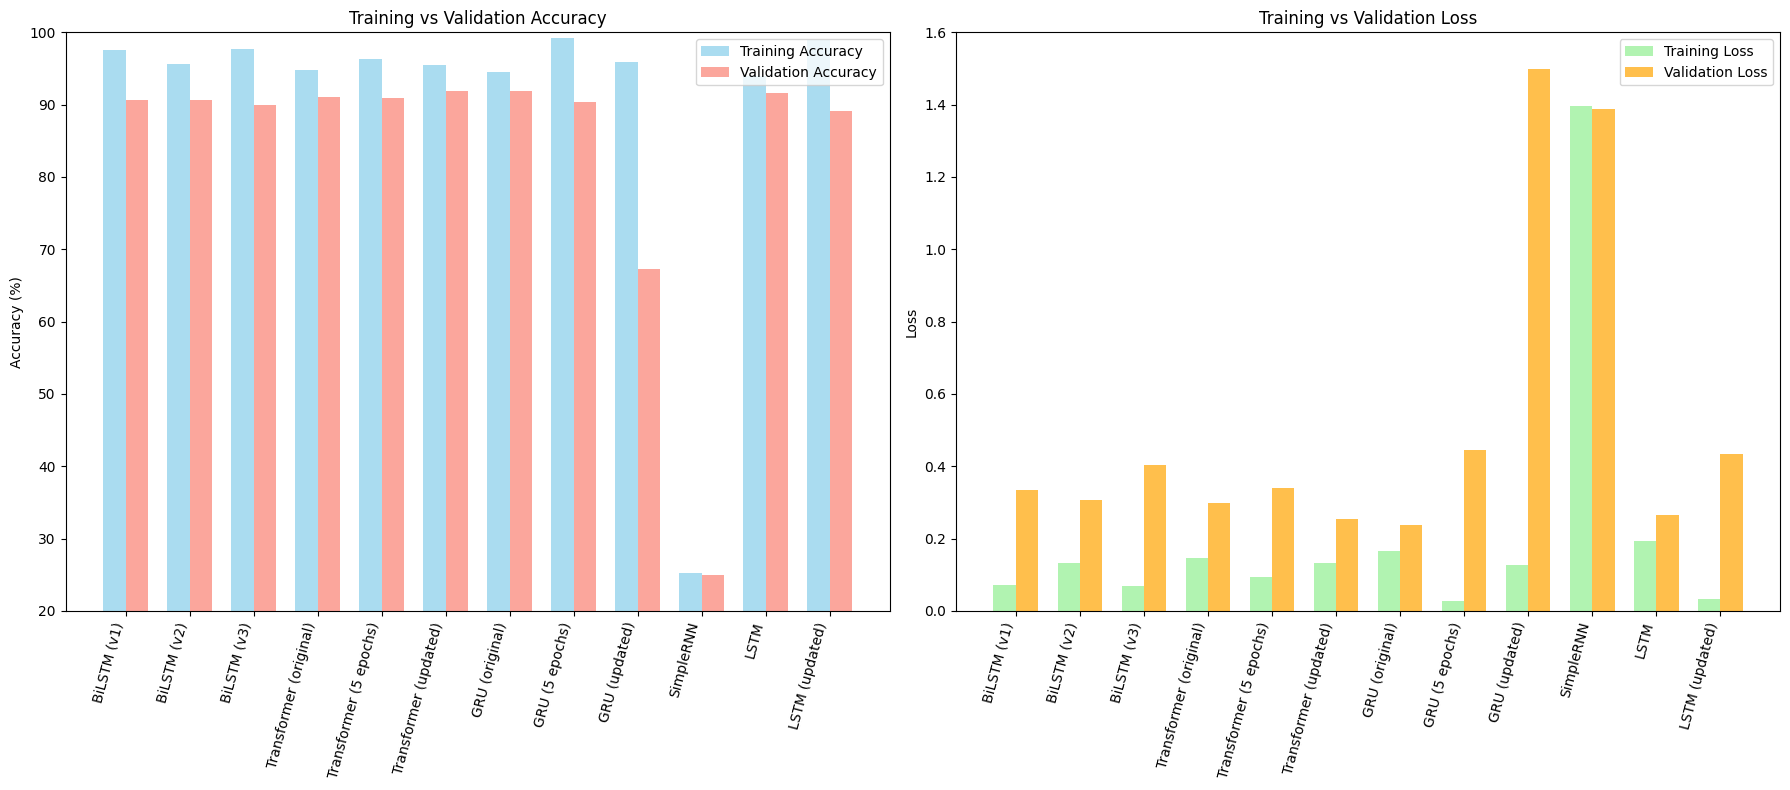

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Models and Variants
models = [
    'BiLSTM (v1)', 'BiLSTM (v2)', 'BiLSTM (v3)',
    'Transformer (original)', 'Transformer (5 epochs)', 'Transformer (updated)',
    'GRU (original)', 'GRU (5 epochs)', 'GRU (updated)',
    'SimpleRNN',
    'LSTM', 'LSTM (updated)'
]

# Accuracy and loss data
train_accuracy = [97.59, 95.68, 97.73, 94.79, 96.32, 95.48, 94.49, 99.15, 95.86, 25.21, 94.03, 98.92]
val_accuracy   = [90.61, 90.71, 89.99, 91.04, 90.96, 91.89, 91.89, 90.38, 67.21, 25.00, 91.65, 89.07]
train_loss     = [0.0724, 0.1322, 0.0686, 0.1468, 0.0933, 0.1329, 0.1644, 0.0260, 0.1283, 1.397, 0.1928, 0.0335]
val_loss       = [0.3339, 0.3076, 0.4023, 0.2997, 0.3398, 0.2529, 0.2364, 0.4437, 1.4974, 1.3873, 0.2658, 0.4333]

# Convert percentage values to actual (float)
train_accuracy = [x for x in train_accuracy]
val_accuracy   = [x for x in val_accuracy]

# Bar width and index setup
bar_width = 0.35
index = np.arange(len(models))

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Accuracy plot
ax[0].bar(index - bar_width/2, train_accuracy, bar_width, label='Training Accuracy', alpha=0.7, color='skyblue')
ax[0].bar(index + bar_width/2, val_accuracy, bar_width, label='Validation Accuracy', alpha=0.7, color='salmon')
ax[0].set_title('Training vs Validation Accuracy')
ax[0].set_ylabel('Accuracy (%)')
ax[0].set_xticks(index)
ax[0].set_xticklabels(models, rotation=75, ha='right')
ax[0].set_ylim([20, 100])
ax[0].legend()

# Loss plot
ax[1].bar(index - bar_width/2, train_loss, bar_width, label='Training Loss', alpha=0.7, color='lightgreen')
ax[1].bar(index + bar_width/2, val_loss, bar_width, label='Validation Loss', alpha=0.7, color='orange')
ax[1].set_title('Training vs Validation Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xticks(index)
ax[1].set_xticklabels(models, rotation=75, ha='right')
ax[1].set_ylim([0, 1.6])
ax[1].legend()

plt.tight_layout()
plt.show()


Bar Chart for Accuracy: The first subplot compares the training accuracy and validation accuracy for each model. The height of the bars represents the accuracy in percentage.

Bar Chart for Loss: The second subplot compares the training loss and validation loss for each model. A lower value is better for loss.

If you want to visualize accuracy and loss changes over epochs (i.e., showing a learning curve), here’s an example for that as well:


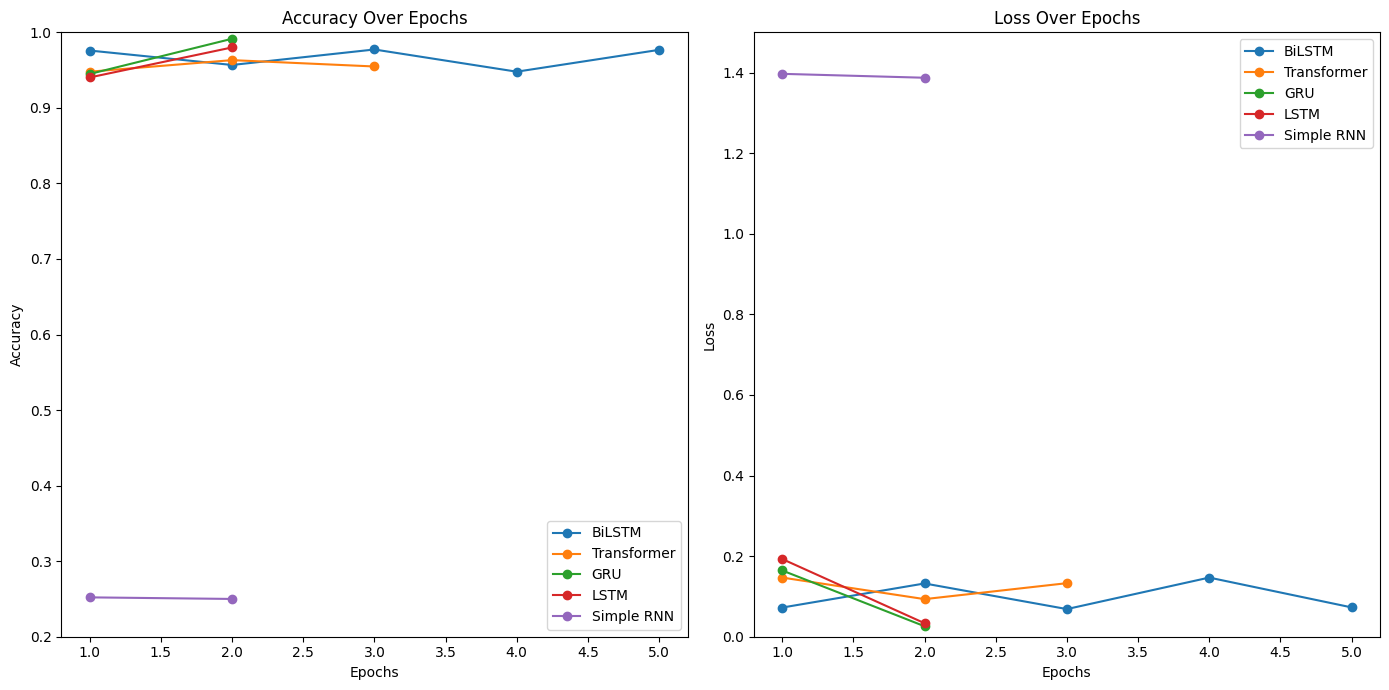

In [44]:
# Epoch ranges for each model
epochs_biLSTM = [1, 2, 3, 4, 5]
epochs_transformer = [1, 2, 3]
epochs_gru = [1, 2]
epochs_simple_rnn = [1, 2]
epochs_lstm = [1, 2]

# Accuracy per epoch
biLSTM_acc = [0.9759, 0.9568, 0.9773, 0.9479, 0.9768]  # Using training accuracy for the plot
transformer_acc = [0.9479, 0.9632, 0.9548]  # Using training accuracy for the plot
gru_acc = [0.9449, 0.9915]  # Using training accuracy for the plot
simple_rnn_acc = [0.2521, 0.2500]  # No update, based on initial value
lstm_acc = [0.9403, 0.9800]  # Using training accuracy for the plot

# Loss per epoch
biLSTM_loss = [0.0724, 0.1322, 0.0686, 0.1468, 0.0728]  # Using training loss for the plot
transformer_loss = [0.1468, 0.0933, 0.1329]  # Using training loss for the plot
gru_loss = [0.1644, 0.0260]  # Using training loss for the plot
simple_rnn_loss = [1.397, 1.3873]  # No update, based on initial value
lstm_loss = [0.1928, 0.0335]  # Using training loss for the plot

# Plot setup
plt.figure(figsize=(14, 7))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_biLSTM, biLSTM_acc, label='BiLSTM', marker='o')
plt.plot(epochs_transformer, transformer_acc, label='Transformer', marker='o')
plt.plot(epochs_gru, gru_acc, label='GRU', marker='o')
plt.plot(epochs_lstm, lstm_acc, label='LSTM', marker='o')
plt.plot(epochs_simple_rnn, simple_rnn_acc, label='Simple RNN', marker='o')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim([0.2, 1.0])
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_biLSTM, biLSTM_loss, label='BiLSTM', marker='o')
plt.plot(epochs_transformer, transformer_loss, label='Transformer', marker='o')
plt.plot(epochs_gru, gru_loss, label='GRU', marker='o')
plt.plot(epochs_lstm, lstm_loss, label='LSTM', marker='o')
plt.plot(epochs_simple_rnn, simple_rnn_loss, label='Simple RNN', marker='o')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim([0, 1.5])
plt.legend()

plt.tight_layout()
plt.show()


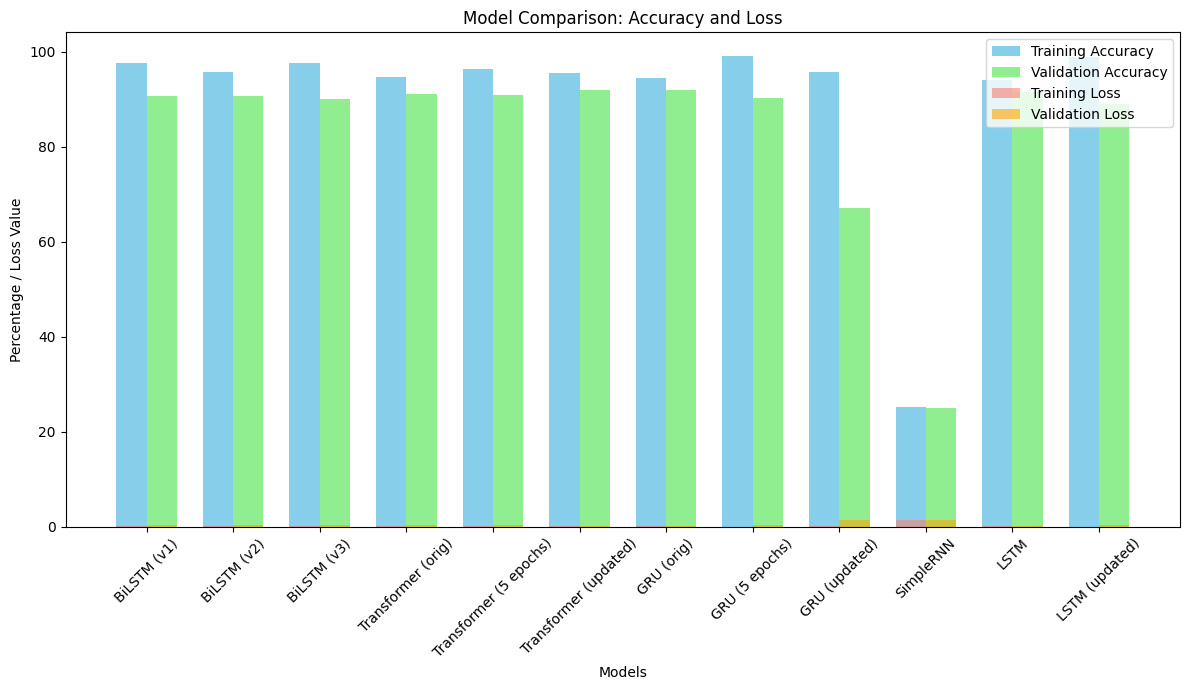

In [43]:
models = [
    'BiLSTM (v1)', 'BiLSTM (v2)', 'BiLSTM (v3)',
    'Transformer (orig)', 'Transformer (5 epochs)', 'Transformer (updated)',
    'GRU (orig)', 'GRU (5 epochs)', 'GRU (updated)',
    'SimpleRNN', 'LSTM', 'LSTM (updated)'
]

train_accuracy = [97.59, 95.68, 97.73, 94.79, 96.32, 95.48, 94.49, 99.15, 95.86, 25.21, 94.03, 98.92]
val_accuracy = [90.61, 90.71, 89.99, 91.04, 90.96, 91.89, 91.89, 90.38, 67.21, 25.00, 91.65, 89.07]
train_loss = [0.0724, 0.1322, 0.0686, 0.1468, 0.0933, 0.1329, 0.1644, 0.026, 0.1283, 1.397, 0.1928, 0.0335]
val_loss = [0.3339, 0.3076, 0.4023, 0.2997, 0.3398, 0.2529, 0.2364, 0.4437, 1.4974, 1.3873, 0.2658, 0.4333]

bar_width = 0.35
index = np.arange(len(models))

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plotting the bars for accuracy
bar1 = ax.bar(index - bar_width/2, train_accuracy, bar_width, label='Training Accuracy', color='skyblue')
bar2 = ax.bar(index + bar_width/2, val_accuracy, bar_width, label='Validation Accuracy', color='lightgreen')

# Plotting the bars for loss
bar3 = ax.bar(index - bar_width/2, train_loss, bar_width, label='Training Loss', color='salmon', alpha=0.6)
bar4 = ax.bar(index + bar_width/2, val_loss, bar_width, label='Validation Loss', color='orange', alpha=0.6)

# Adding labels, title, and legend
ax.set_xlabel('Models')
ax.set_ylabel('Percentage / Loss Value')
ax.set_title('Model Comparison: Accuracy and Loss')
ax.set_xticks(index)
ax.set_xticklabels(models, rotation=45)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()


My top Models

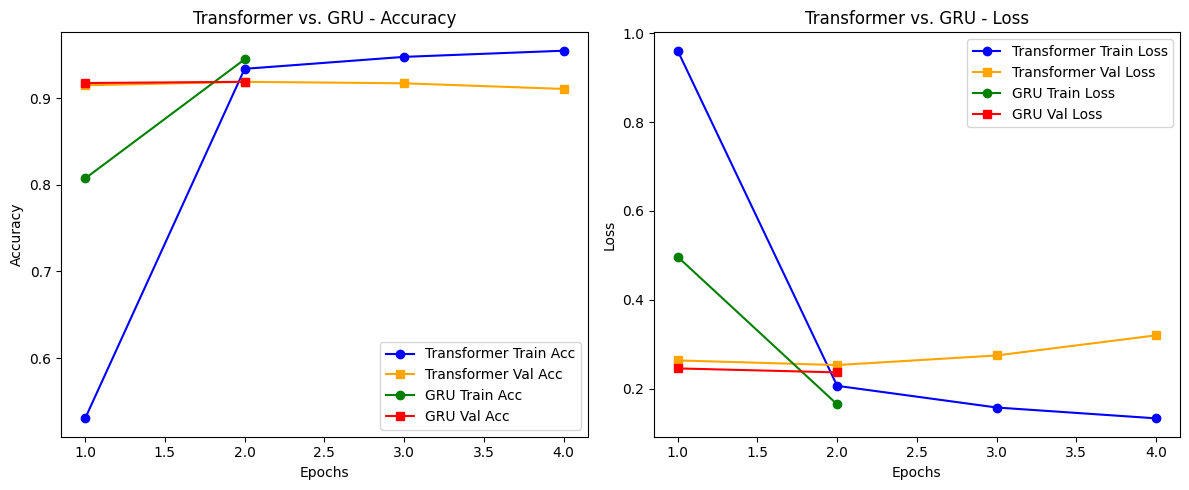

In [46]:
# Transformer Model Scores
transformer_epochs = [1, 2, 3, 4]
transformer_train_acc = [0.5305, 0.9339, 0.9477, 0.9548]
transformer_val_acc = [0.9149, 0.9189, 0.9172, 0.9107]
transformer_train_loss = [0.9607, 0.2061, 0.1573, 0.1329]
transformer_val_loss = [0.2633, 0.2529, 0.2745, 0.3198]

# GRU Model Scores
gru_epochs = [1, 2]
gru_train_acc = [0.8074, 0.9449]
gru_val_acc = [0.9175, 0.9189]
gru_train_loss = [0.4966, 0.1644]
gru_val_loss = [0.2453, 0.2364]

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(transformer_epochs, transformer_train_acc, 'o-', label="Transformer Train Acc", color="blue")
plt.plot(transformer_epochs, transformer_val_acc, 's-', label="Transformer Val Acc", color="orange")
plt.plot(gru_epochs, gru_train_acc, 'o-', label="GRU Train Acc", color="green")
plt.plot(gru_epochs, gru_val_acc, 's-', label="GRU Val Acc", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Transformer vs. GRU - Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(transformer_epochs, transformer_train_loss, 'o-', label="Transformer Train Loss", color="blue")
plt.plot(transformer_epochs, transformer_val_loss, 's-', label="Transformer Val Loss", color="orange")
plt.plot(gru_epochs, gru_train_loss, 'o-', label="GRU Train Loss", color="green")
plt.plot(gru_epochs, gru_val_loss, 's-', label="GRU Val Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Transformer vs. GRU - Loss")
plt.legend()

plt.tight_layout()
plt.show()


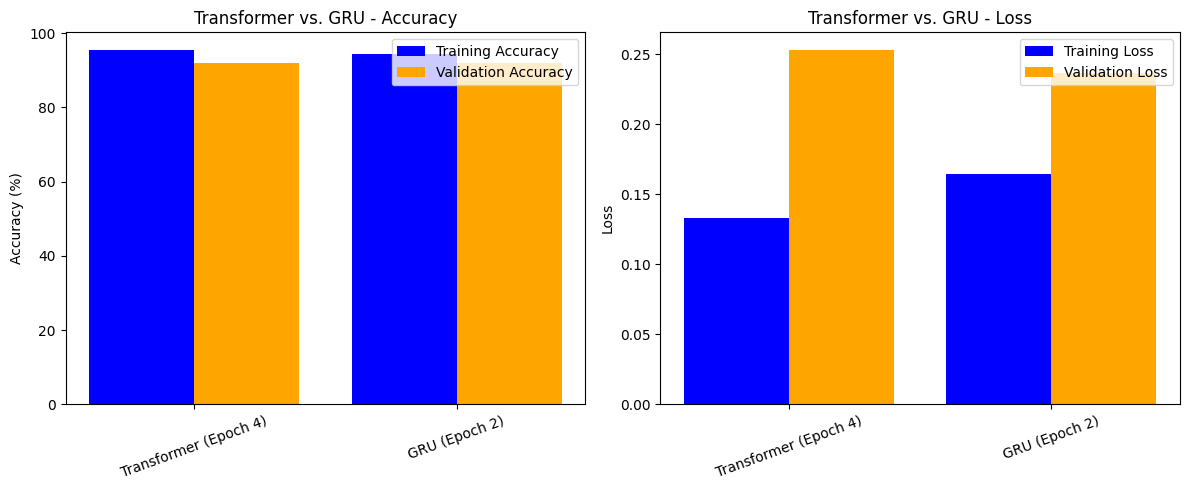

In [48]:

# Model names
models = ["Transformer (Epoch 4)", "GRU (Epoch 2)"]

# Accuracy scores
training_accuracy = [95.48, 94.49]
validation_accuracy = [91.89, 91.89]

# Loss scores
training_loss = [0.1329, 0.1644]
validation_loss = [0.2529, 0.2364]

# Bar width
width = 0.4
x = np.arange(len(models))

# Create bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy Bar Chart
axes[0].bar(x - width/2, training_accuracy, width, label="Training Accuracy", color="blue")
axes[0].bar(x + width/2, validation_accuracy, width, label="Validation Accuracy", color="orange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Transformer vs. GRU - Accuracy")
axes[0].legend()

# Loss Bar Chart
axes[1].bar(x - width/2, training_loss, width, label="Training Loss", color="blue")
axes[1].bar(x + width/2, validation_loss, width, label="Validation Loss", color="orange")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20)
axes[1].set_ylabel("Loss")
axes[1].set_title("Transformer vs. GRU - Loss")
axes[1].legend()

plt.tight_layout()
plt.show()
